## Test Events
Notebook for selecting events to be used for testing of the NN-GMM

In [1]:
from pathlib import Path
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import pygmt
from pygmt_helper import plotting

import nn_gmm as nng

In [ ]:
seed = 123

In [4]:
np.random.seed(seed)

n_events = 25

In [ ]:
imdb_ffp = Path("/Users/claudy/dev/work/data/nn_gmm/202505_CS200m_imdb.db")
nhm_flt_ffp = Path("/Users/claudy/dev/work/data/nn_gmm/source/NZ_FLTmodel_2010.txt")

In [6]:
with nng.IMDB(imdb_ffp, readonly=True) as imdb:
    event_df = imdb.get_event_df().set_index("event_id")

In [7]:
# Randomly select events
test_event_df = event_df.sample(n=n_events, random_state=seed)

In [8]:
print(f"Test events:\n{'\n'.join(test_event_df.index.values)}")

Test events:
TuhuaS01
Kakapo
Okaia3
KaiwaraS
Kaingaroa
LongVlly
WhirinakiW
Lachlan3
TaieriR
Tauranga02
Ohiwa01
Thornton02
ShannonA
GeorgeR1
KairakauN
Lowry
Swedge1
Opawa
Pahaua
PoranagR
PaeroaALL
AldermanE06
Tuakana05
PaValley
Ngangiho


In [9]:
map_data = plotting.NZMapData.load(high_res_topo=False)

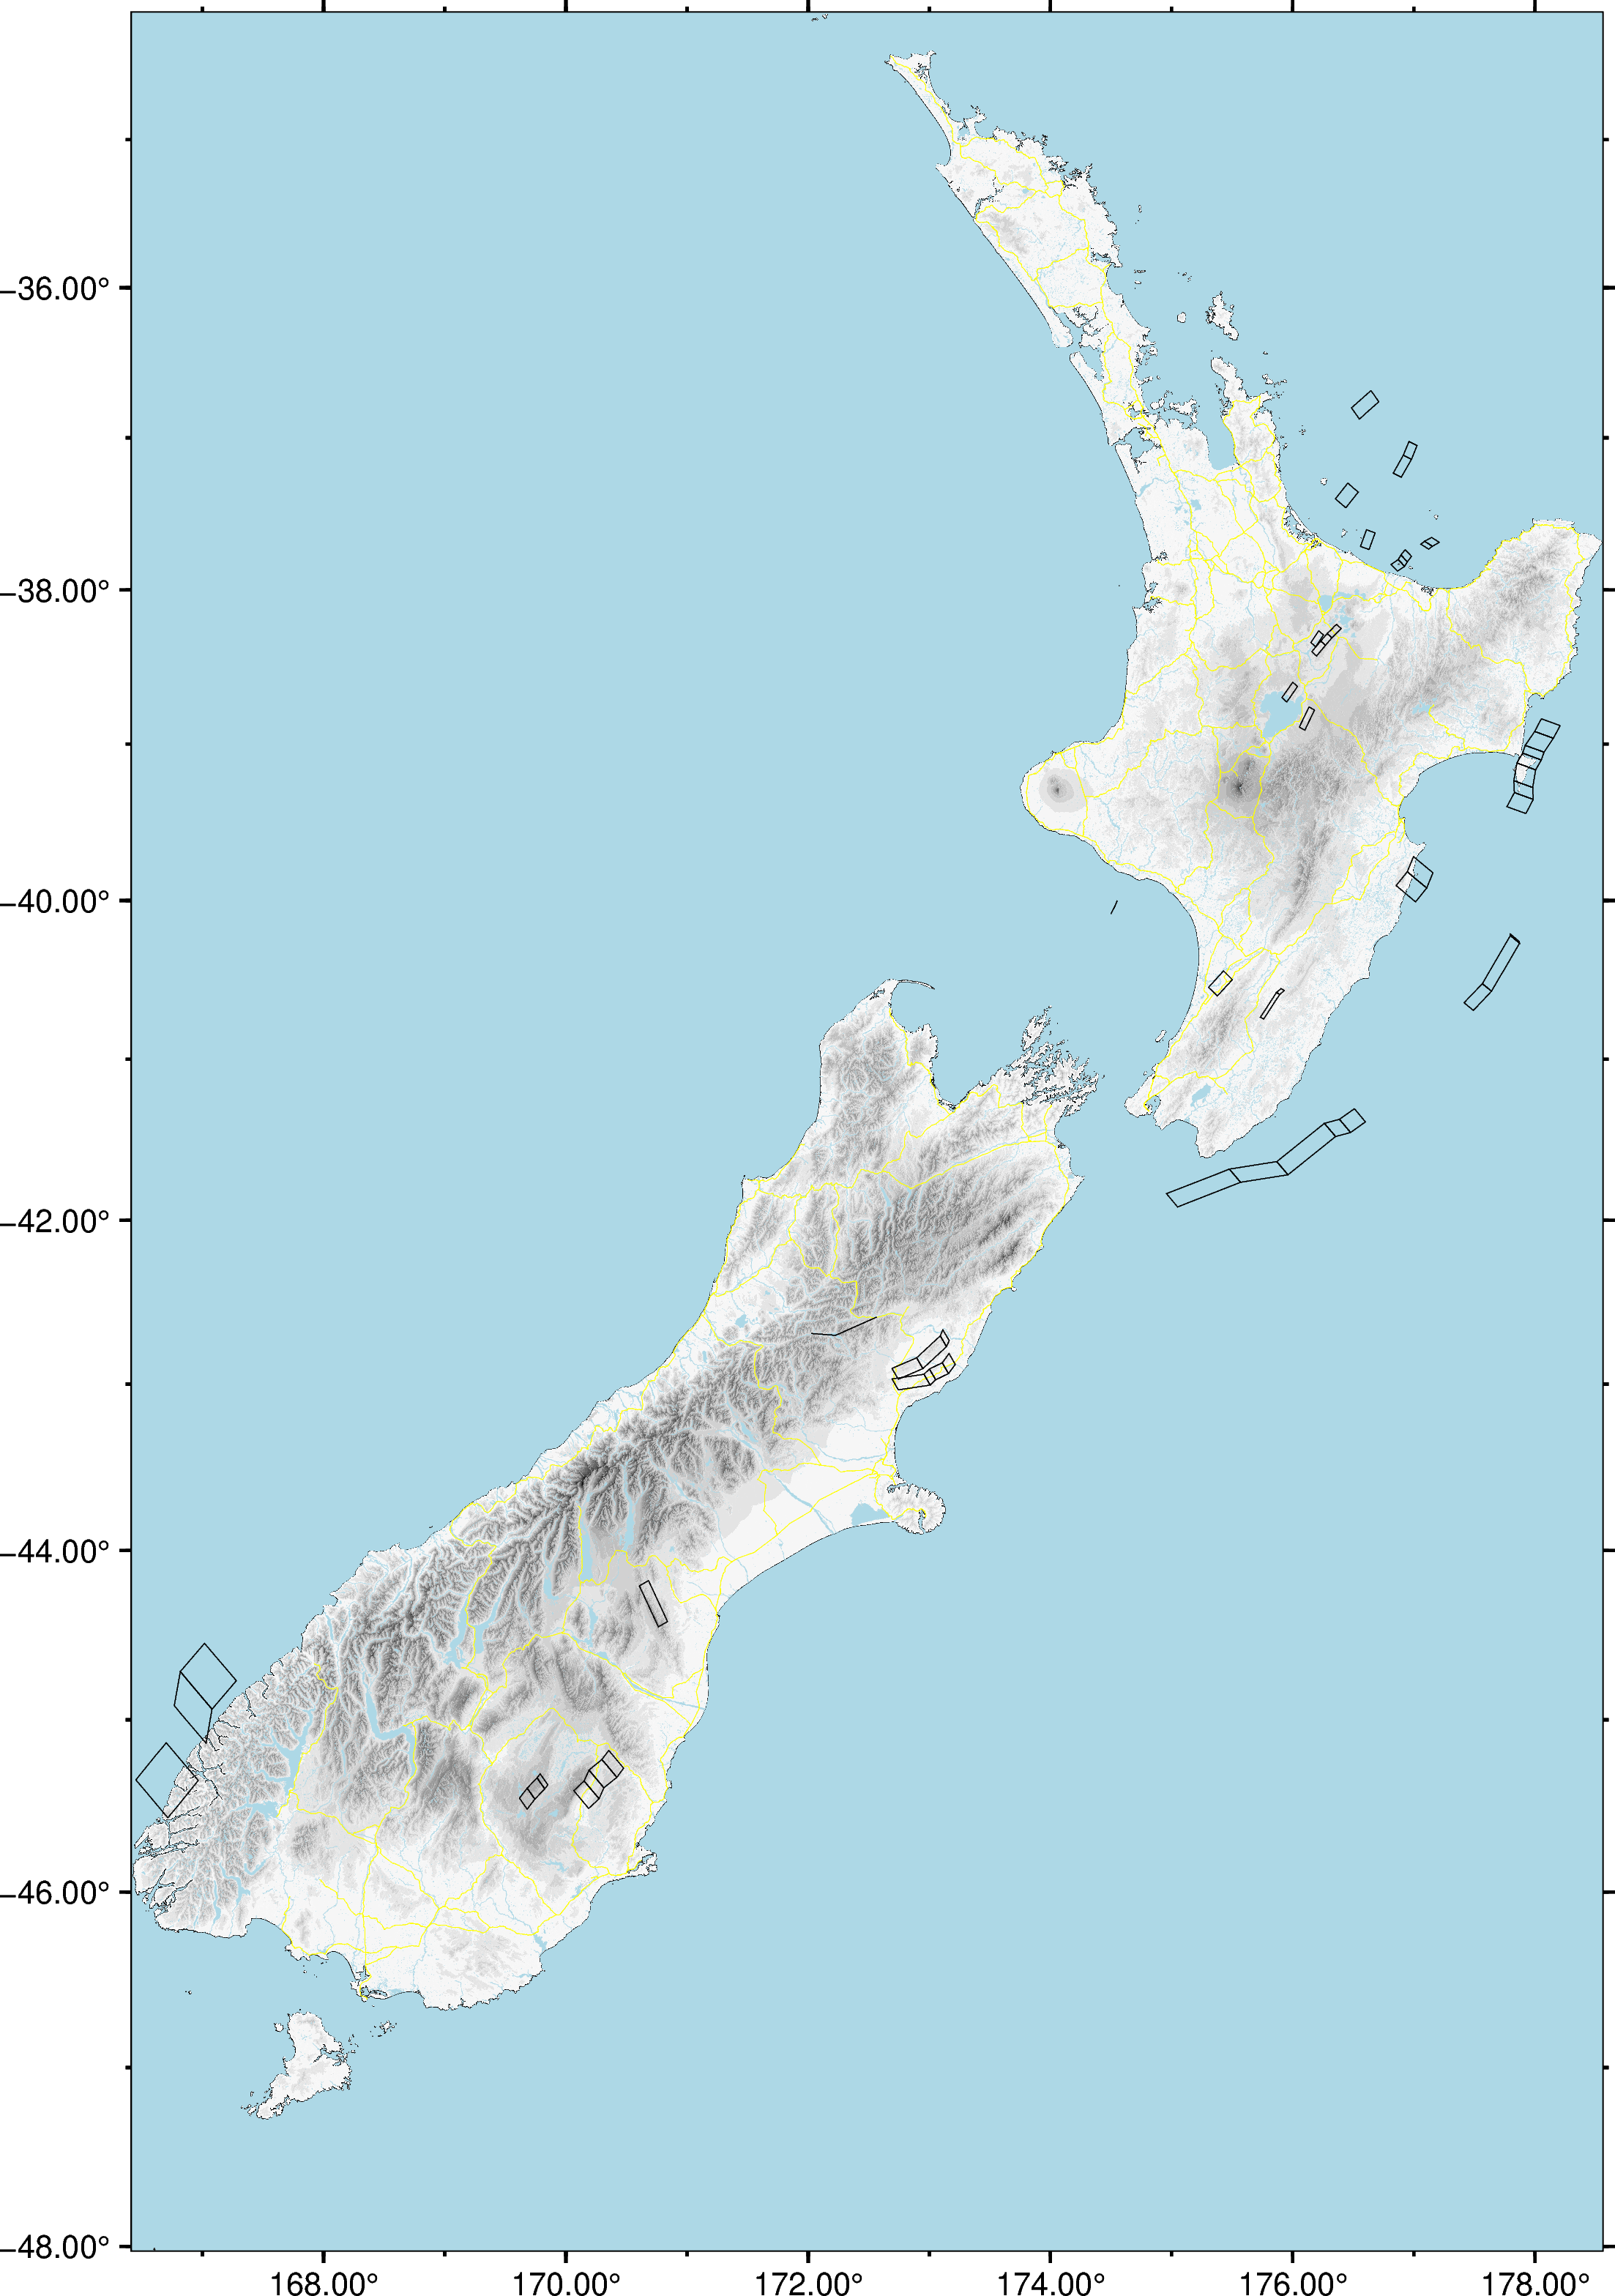

In [10]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    fig = plotting.gen_region_fig(
        region="NZ",
        map_data=map_data,
        plot_kwargs={
                "highway_pen_width": 0.1,
                "coastline_pen_width": 0.01,
                "topo_cmap": "gray",  # etopo1 geo
                "topo_cmap_min": 0,
                "topo_cmap_max": 3700,
                "topo_cmap_inc": 250,
                "topo_cmap_reverse": True,
        },
        config_options=dict(
            MAP_FRAME_TYPE="plain",
            FORMAT_GEO_MAP="ddd.xx",
            MAP_GRID_PEN="0.5p,gray",
            MAP_TICK_PEN_PRIMARY="1p,black",
            MAP_FRAME_PEN="1p,black",
            MAP_FRAME_AXES="WSne",
        ),
        plot_roads=False,
    )

# Plot the events
faults = nng.utils.get_faults(nhm_flt_ffp)
for cur_event in test_event_df.index.values:
    fault = faults[cur_event]

    for cur_plane in fault.planes:
        fig.plot(x=cur_plane.corners[:, 1], y=cur_plane.corners[:, 0])
        fig.plot(
            x=[cur_plane.corners[0, 1], cur_plane.corners[-1, 1]],
            y=[cur_plane.corners[0, 0], cur_plane.corners[-1, 0]],
        )

fig.show()

In [11]:
event_df.magnitude.max()


8.230224043414996

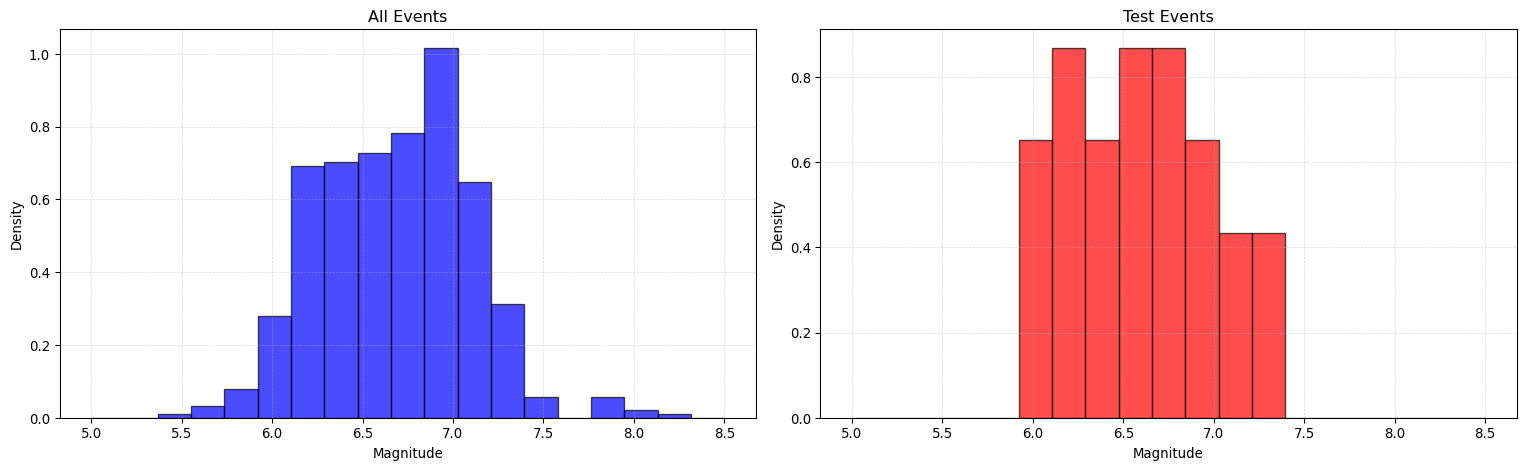

In [12]:
bins = np.linspace(5.0, 8.5, 20)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.hist(event_df["magnitude"], bins=bins, color="blue", edgecolor="black", alpha=0.7, density=True)
ax1.set_xlabel("Magnitude")
ax1.set_ylabel("Density")
ax1.set_title("All Events")
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")

ax2.hist(test_event_df["magnitude"], bins=bins, color="red", edgecolor="black", alpha=0.7, density=True)
ax2.set_xlabel("Magnitude")
ax2.set_ylabel("Density")
ax2.set_title("Test Events")
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")

fig.tight_layout()